# CHỦ ĐỀ: KHỦNG HOẢNG TỶ LỆ HOÀN TRẢ SẢN PHẨM (THE CRISIS OF PRODUCT RETURN RATES)

## 1. Bối cảnh & Đặt vấn đề tổng thể
Trong lĩnh vực thương mại điện tử thời trang, tỷ lệ hoàn trả sản phẩm (Return Rate) luôn là một trong những điểm nghẽn đau đầu nhất đối với các nhà quản trị. Khác với các ngành hàng điện tử tiêu dùng hay nhu yếu phẩm, thời trang mang tính cá nhân hóa cao và phụ thuộc lớn vào trải nghiệm xúc giác cũng như độ vừa vặn của sản phẩm. 

Việc khách hàng không thể trực tiếp thử nghiệm sản phẩm trước khi mua dẫn đến một hành vi mua sắm đặc trưng gọi là "bracket buying" (mua bao vây). Đặc biệt, với hình thức thanh toán COD (Cash on Delivery), rủi ro tài chính ban đầu cho người mua gần như bằng 0, vô tình dung túng cho tâm lý mua sắm bốc đồng. Việc này tạo ra một gánh nặng khổng lồ cho hệ thống logistics ngược (Reverse Logistics), gây thất thoát doanh thu và xói mòn biên lợi nhuận.

## 2. Mục tiêu phân tích
Báo cáo này được thực hiện nhằm mục đích lượng hóa và chẩn đoán khủng hoảng hoàn trả qua 3 bước phân tích chính:
- **Bước 1:** Phân tích Tác động của Phương thức thanh toán (COD vs Others).
- **Bước 2:** Phân tích và phát hiện hành vi "Bracket Buying" (Mua để thử).
- **Bước 3:** Phân tích Cấu trúc rủi ro để chuẩn bị dữ liệu (Feature Engineering) cho mô hình Học máy Dự đoán hoàn trả (Predictive Model).

---
**Giải thích thuật ngữ** 

Reverse Logistics (Logistics ngược):
- Đề cập đến chuỗi hoạt động thu hồi sản phẩm từ tay người tiêu dùng cuối cùng để đưa về lại trung tâm phân phối. Tốn kém và phức tạp hơn logistics xuôi (forward logistics).

Return Rate (Tỷ lệ hoàn trả):
- Chỉ số KPI đo lường tỷ lệ phần trăm giữa số lượng sản phẩm bị trả lại so với tổng số lượng sản phẩm đã bán.

Bracket Buying (Mua bao vây / Mua để thử):
- Khách hàng cố ý mua nhiều kích cỡ (Size S, M, L) hoặc nhiều màu sắc của cùng một sản phẩm. Giữ lại một món ưng ý và trả lại toàn bộ phần còn lại.

COD (Cash on Delivery):
- Thanh toán khi nhận hàng. Chuyển toàn bộ rủi ro của giao dịch từ người mua sang người bán.


---
## **BƯỚC 1: PHÂN TÍCH TÁC ĐỘNG CỦA PHƯƠNG THỨC THANH TOÁN ĐẾN TỶ LỆ HOÀN TRẢ**
### 1. Bài toán
Kiểm chứng giả thuyết: Phương thức thanh toán khi nhận hàng (COD) có thực sự là tác nhân chính làm gia tăng xác suất hoàn trả đơn hàng so với các hình thức trả trước (Thẻ tín dụng, Ví điện tử) hay không?

### 2. Động lực thực hiện
Nếu COD thực sự là nguyên nhân cốt lõi, doanh nghiệp có thể đưa ra quyết định cứng rắn (ví dụ: ẩn nút thanh toán COD) đối với những tập khách hàng có rủi ro cao, chấp nhận rớt một tỷ lệ nhỏ chuyển đổi để bảo vệ biên lợi nhuận vận hành.


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15072\2109221517.py:8: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_items = pd.read_csv('../dataset/order_items.csv')


Tỷ lệ hoàn trả tổng thể (Global Return Rate): 5.59%

Bảng phân bổ tỷ lệ hoàn trả theo phương thức thanh toán:
  payment_method   count  return_rate_pct
2            cod  106965         8.920675
1  bank_transfer   35543         5.030526
4         paypal  107230         5.020983
0      apple_pay   71510         4.997902
3    credit_card  393421         4.996683


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15072\2109221517.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=payment_returns, x='payment_method', y='return_rate_pct', palette='Reds_r')


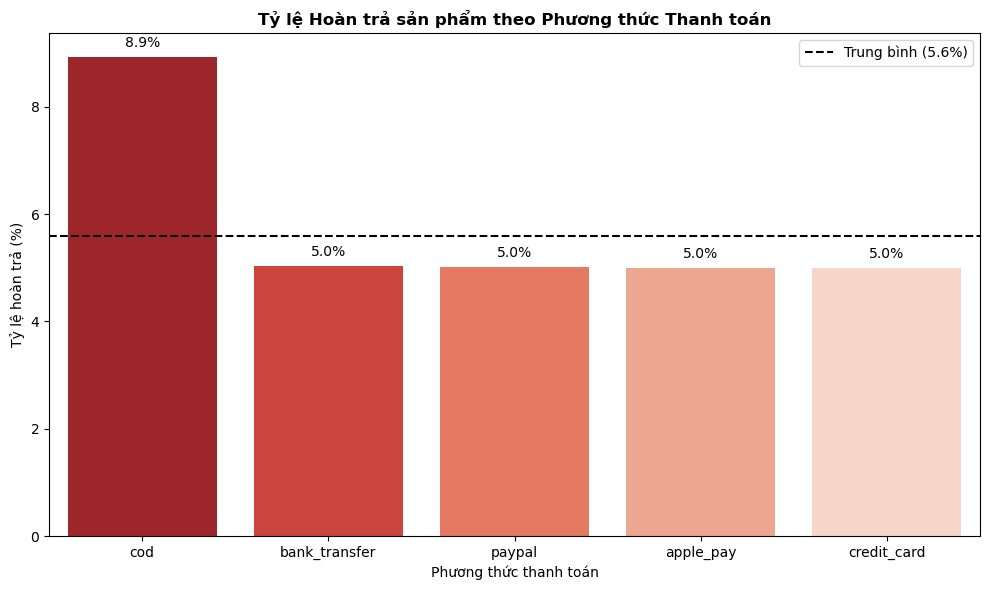

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu
df_orders = pd.read_csv('../dataset/orders.csv')
df_items = pd.read_csv('../dataset/order_items.csv')
df_returns = pd.read_csv('../dataset/returns.csv')

# 2. Xây dựng Dataframe cơ sở ở cấp độ dòng sản phẩm (order-item level)
df_base = pd.merge(df_items, df_orders[['order_id', 'payment_method', 'customer_id']], on='order_id', how='left')

# 3. Tạo biến mục tiêu (Target Variable): is_returned
# Lấy danh sách các đơn hàng có trong bảng trả hàng
returned_orders = df_returns['order_id'].unique()
df_base['is_returned'] = df_base['order_id'].isin(returned_orders).astype(int)

# 4. Tính toán Tỷ lệ hoàn trả tổng thể & Theo hình thức thanh toán
global_return_rate = df_base['is_returned'].mean() * 100
print(f"Tỷ lệ hoàn trả tổng thể (Global Return Rate): {global_return_rate:.2f}%\n")

payment_returns = df_base.groupby('payment_method')['is_returned'].agg(['count', 'mean']).reset_index()
payment_returns['return_rate_pct'] = payment_returns['mean'] * 100
payment_returns = payment_returns.sort_values('return_rate_pct', ascending=False)

print("Bảng phân bổ tỷ lệ hoàn trả theo phương thức thanh toán:")
print(payment_returns[['payment_method', 'count', 'return_rate_pct']])

# 5. Vẽ biểu đồ trực quan
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=payment_returns, x='payment_method', y='return_rate_pct', palette='Reds_r')
plt.axhline(global_return_rate, color='black', linestyle='--', label=f'Trung bình ({global_return_rate:.1f}%)')

# Thêm nhãn dữ liệu lên cột
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.title('Tỷ lệ Hoàn trả sản phẩm theo Phương thức Thanh toán', fontweight='bold')
plt.ylabel('Tỷ lệ hoàn trả (%)')
plt.xlabel('Phương thức thanh toán')
plt.legend()
plt.tight_layout()
plt.show()


### 3. Nhận xét Chẩn đoán (Diagnostic):

Dưới góc độ phân tích kinh doanh, biểu đồ trên là một "tín hiệu báo động" cực kỳ rõ ràng về mặt vận hành và tài chính:

- **Sự phân hóa tuyệt đối (The Prepaid vs. Postpaid Divide):** Tất cả các hình thức thanh toán trả trước (Bank Transfer, PayPal, Apple Pay, Credit Card) đều chia sẻ một mức tỷ lệ hoàn trả thấp, đồng nhất ở mức **5.0%**. Trong khi đó, tỷ lệ hoàn trả của **COD (8.9%)** cao gấp **1.78 lần** so với nhóm trả trước và kéo tỷ lệ trung bình toàn hệ thống lên 5.6%.
- **Tâm lý học hành vi (Commitment Bias):** Khách hàng sử dụng hình thức trả trước đã tạo ra một cam kết tài chính (trả tiền ngay), buộc họ phải cân nhắc kỹ lưỡng về sản phẩm trước khi mua. Ngược lại, COD có rào cản rủi ro bằng 0, vô tình dung túng cho tâm lý mua sắm bốc đồng (Impulse Buying).
- **Ảo tưởng Doanh thu (GMV Illusion):** COD có thể giúp tăng trưởng chỉ số GMV nhanh chóng, nhưng mức hoàn trả 8.9% đang xói mòn trực tiếp lợi nhuận thuần (Net Revenue) vì doanh nghiệp phải gánh chịu toàn bộ chi phí Logistics ngược (ship 2 chiều, kiểm định, đóng gói lại).

### 4. Đề xuất hành động (Prescriptive) & Tích hợp Mô hình:

**Về mặt kinh doanh (Business Actions):**
- **Incentivize Prepaid:** Không nên cấm COD một cách cực đoan. Thay vào đó, thiết kế chiến dịch: *"Freeship 100% hoặc Giảm thêm 5% khi thanh toán qua thẻ/ví điện tử"*. Chi phí giảm giá 5% này là bài toán đánh đổi rẻ hơn rất nhiều so với việc gánh chịu tỷ lệ hoàn trả 8.9% từ COD.
- **Dynamic Checkout:** Chặn hiển thị phương thức COD đối với các giỏ hàng giá trị cao bất thường hoặc với tập khách hàng từng có lịch sử bom hàng.

**Về khâu chuẩn bị Mô hình (Modeling / Feature Engineering):**
- **Binarization:** Vì 4 hình thức trả trước có tỷ lệ return giống hệt nhau (5.0%), khi đưa dữ liệu vào Mô hình Học máy (Machine Learning) ở các notebook tiếp theo, ta chỉ cần tạo một biến nhị phân duy nhất: `payment_is_cod` (1 nếu COD, 0 nếu không).
- **Kết hợp rủi ro kép:** Phương thức COD sẽ càng nguy hiểm nếu khách hàng mua nhiều món cùng lúc để thử. Điều này dẫn dắt chúng ta đến việc phải kiểm tra giả thuyết về số lượng mặt hàng trong giỏ ở **BƯỚC 2 (Phân tích hành vi Bracket Buying)** ngay dưới đây.


---
## **BƯỚC 2: PHÂN TÍCH HÀNH VI MUA BAO VÂY (BRACKET BUYING)**
### 1. Bài toán
Làm thế nào để phát hiện tập khách hàng đang biến phòng ngủ của họ thành "phòng thử đồ ảo" (mua nhiều sản phẩm cùng lúc để thử và trả lại phần lớn)?

### 2. Động lực thực hiện
Nếu phát hiện được mẫu hành vi "giỏ hàng có nhiều mặt hàng" tỷ lệ thuận với "xác suất trả hàng", thuật toán AI sau này có thể can thiệp ngay lập tức khi giỏ hàng vượt quá số lượng ngưỡng an toàn.


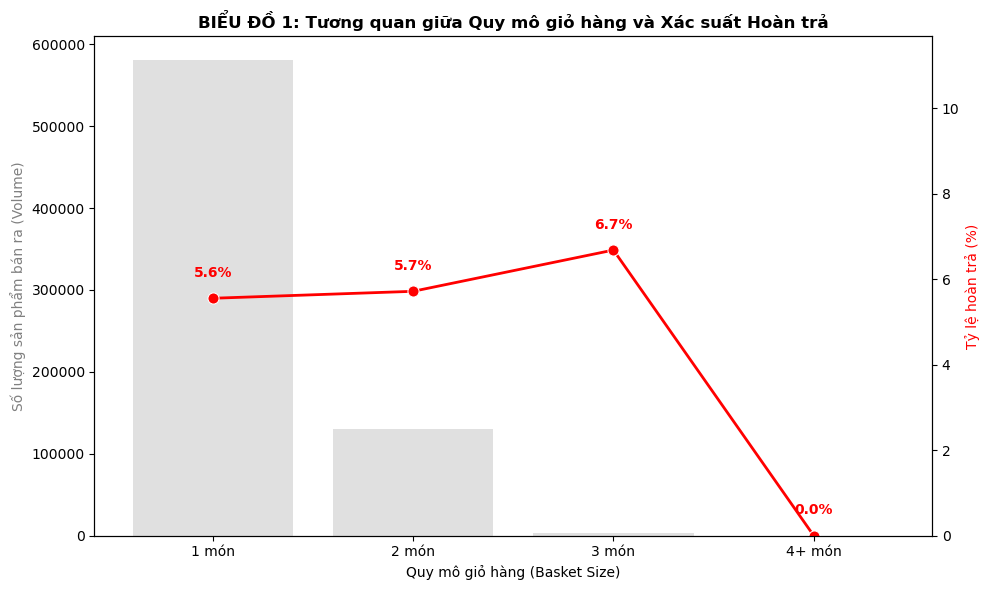

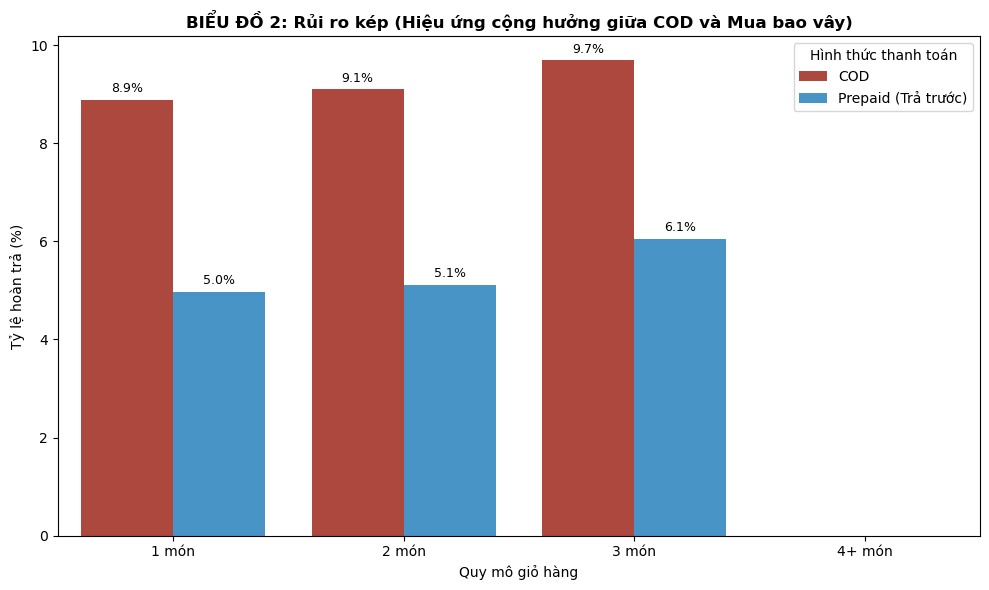

In [6]:
# 1. Đếm số lượng sản phẩm trong mỗi đơn hàng và phân nhóm (Binning)
order_sizes = df_base.groupby('order_id').size().reset_index(name='items_in_order')
df_bracket = pd.merge(df_base, order_sizes, on='order_id', how='left')

# Tạo biến phân nhóm Basket Size
conditions = [
    df_bracket['items_in_order'] == 1,
    df_bracket['items_in_order'] == 2,
    df_bracket['items_in_order'] == 3,
    df_bracket['items_in_order'] >= 4
]
choices = ['1 món', '2 món', '3 món', '4+ món']

# VÁ LỖI TẠI ĐÂY: Thêm default='Khác' để đồng bộ định dạng chuỗi (String)
df_bracket['basket_size_group'] = np.select(conditions, choices, default='Khác')

# Gom nhóm thanh toán (COD vs Prepaid) để phân tích Rủi ro kép
df_bracket['payment_type'] = np.where(df_bracket['payment_method'] == 'cod', 'COD', 'Prepaid (Trả trước)')

# 2. Tính toán Data cho Biểu đồ 1 (Volume & Return Rate)
bracket_stats = df_bracket.groupby('basket_size_group')['is_returned'].agg(['count', 'mean']).reset_index()
bracket_stats['return_rate_pct'] = bracket_stats['mean'] * 100

# 3. Vẽ biểu đồ 1: Tương quan tuyến tính (Dual Axis Chart)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Cột Bar: Số lượng mặt hàng bán ra
sns.barplot(data=bracket_stats, x='basket_size_group', y='count', color='lightgrey', ax=ax1, alpha=0.7, 
            order=['1 món', '2 món', '3 món', '4+ món']) # Ép thứ tự hiển thị
ax1.set_ylabel('Số lượng sản phẩm bán ra (Volume)', color='grey')
ax1.set_xlabel('Quy mô giỏ hàng (Basket Size)')

# Đường Line: Tỷ lệ hoàn trả
ax2 = ax1.twinx()
sns.lineplot(data=bracket_stats, x='basket_size_group', y='return_rate_pct', color='red', marker='o', 
             linewidth=2, ax=ax2, markersize=8)
ax2.set_ylabel('Tỷ lệ hoàn trả (%)', color='red')
ax2.set_ylim(0, bracket_stats['return_rate_pct'].max() + 5)

for x, y in zip(range(len(bracket_stats)), bracket_stats['return_rate_pct']):
    ax2.text(x, y + 0.5, f'{y:.1f}%', color='red', fontweight='bold', ha='center')

plt.title('BIỂU ĐỒ 1: Tương quan giữa Quy mô giỏ hàng và Xác suất Hoàn trả', fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Vẽ biểu đồ 2: Hiệu ứng rủi ro kép (Toxic Combo: COD x Bracket Buying)
plt.figure(figsize=(10, 6))
combo_stats = df_bracket.groupby(['basket_size_group', 'payment_type'])['is_returned'].mean().reset_index()
combo_stats['return_rate_pct'] = combo_stats['is_returned'] * 100

ax = sns.barplot(data=combo_stats, x='basket_size_group', y='return_rate_pct', hue='payment_type', 
                 palette=['#c0392b', '#3498db'], order=['1 món', '2 món', '3 món', '4+ món'])

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=9)

plt.title('BIỂU ĐỒ 2: Rủi ro kép (Hiệu ứng cộng hưởng giữa COD và Mua bao vây)', fontweight='bold')
plt.ylabel('Tỷ lệ hoàn trả (%)')
plt.xlabel('Quy mô giỏ hàng')
plt.legend(title='Hình thức thanh toán')
plt.tight_layout()
plt.show()


### 3. Nhận xét Chẩn đoán (Diagnostic Insights):

- **Thực tế phân bổ quy mô giỏ hàng (Biểu đồ 1):** Dữ liệu cho thấy hành vi mua sắm của tập khách hàng này hầu như đạt giới hạn tối đa ở mốc 3 sản phẩm (nhóm "4+ món" có số lượng tiệm cận 0). Mặc dù giỏ hàng "1 món" chiếm tỷ trọng áp đảo về mặt số lượng, nhưng đường xu hướng (Trendline) đã chứng minh rõ ràng: Quy mô giỏ hàng càng tăng (từ 1 lên 2 và đỉnh điểm là 3 món), tỷ lệ hoàn trả càng tịnh tiến (từ 5.6% lên 6.7%). Hành vi "Bracket Buying" là có thật dù quy mô giỏ hàng không quá lớn.
- **Hiệu ứng Rủi ro Kép cực đoan (Biểu đồ 2):** Khi bóc tách sự cộng hưởng giữa Hình thức thanh toán và Số lượng sản phẩm, mức độ rủi ro hiện lên vô cùng rõ ràng. Một giỏ hàng "3 món" nếu thanh toán trả trước (Prepaid) thì tỷ lệ hoàn trả chỉ nhích nhẹ lên 6.1%. Thế nhưng, cũng giỏ hàng "3 món" đó nếu đặt qua **COD**, tỷ lệ hoàn trả đã nhảy vọt lên mức **9.7%** (gần chạm ngưỡng 10%, tức cứ 10 đơn thì 1 đơn bị trả về). Tổ hợp (Giỏ hàng 3 món x COD) chính là phân khúc độc hại (Toxic Segment) nhất của hệ thống.

### 4. Đề xuất hành động (Prescriptive) & Chuẩn bị Modeling:

- **Tìm ra "Tipping Point" (Ngưỡng bùng phát):** Dữ liệu đã chỉ ra mốc 3 sản phẩm là giới hạn rủi ro cao nhất. Doanh nghiệp cần thiết lập ngay một "Hard Rule" trên hệ thống: **Chỉ cho phép thanh toán COD với đơn hàng tối đa 2 sản phẩm.** Từ sản phẩm thứ 3 trở lên, tự động ẩn nút COD và yêu cầu thanh toán thẻ/ví điện tử.
- **Tạo Đặc trưng tương tác (Interaction Feature) cho Machine Learning:** Thay vì chỉ dùng 2 biến độc lập, khi chuyển sang bước Xây dựng mô hình (Notebook 03), chúng ta nên tạo một biến phân loại rủi ro (Risk Flag): `is_high_risk_order = 1` nếu (`payment_method == 'COD'` VÀ `items_in_order >= 3`), ngược lại là `0`. Cột feature này sẽ giúp thuật toán phân loại đơn hàng trả về kết quả dự đoán với độ chính xác (Precision) cao hơn rất nhiều.


## **BƯỚC 3: HỘI CHỨNG "FOMO" TRONG CÁC KỲ KHUYẾN MÃI (DISCOUNT-DRIVEN RETURNS)**
### 1. Bài toán
Các chương trình khuyến mãi (Flash Sale, Voucher) được tung ra để tăng doanh thu. Nhưng liệu việc áp dụng mã giảm giá có đang kích thích tâm lý "sợ bỏ lỡ" (FOMO - Fear Of Missing Out), khiến khách hàng chốt đơn vội vàng mà không suy nghĩ kỹ, dẫn đến tỷ lệ hoàn trả cao hơn khi nhận hàng?

### 2. Động lực thực hiện
Nếu chứng minh được các đơn hàng áp dụng khuyến mãi có tỷ lệ trả về cao bất thường, doanh nghiệp sẽ phải đánh giá lại hiệu quả thực sự (Net ROI) của các chiến dịch Marketing, thay vì chỉ nhìn vào doanh thu bề nổi.


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15072\4019748276.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_stats = df_base.groupby('discount_tier')['is_returned'].agg(['count', 'mean']).reset_index()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15072\4019748276.py:18: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  ax = sns.pointplot(data=tier_stats, x='discount_tier', y='return_rate_pct',


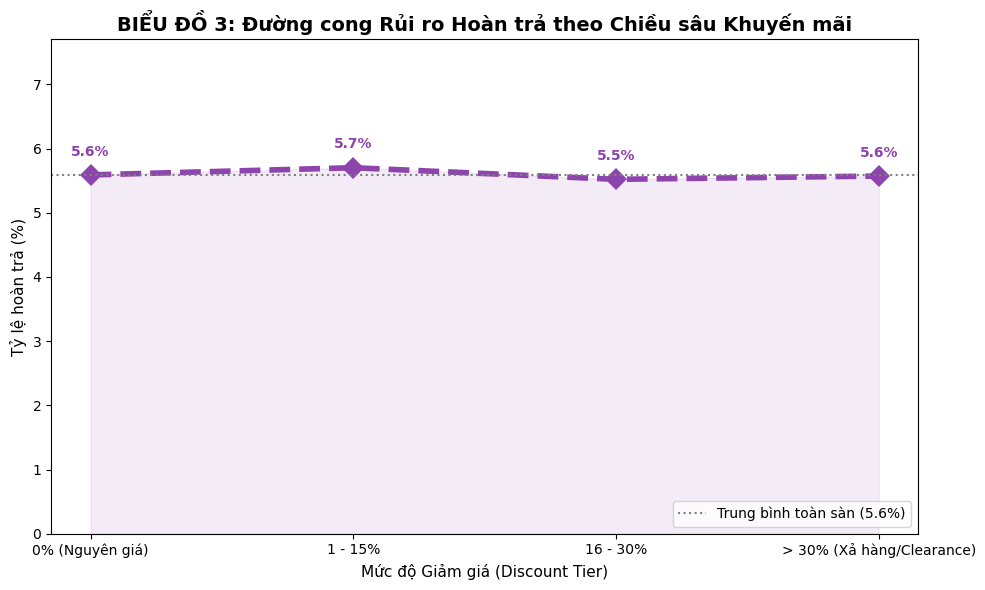

In [9]:
# 1. Tính toán Chiều sâu Khuyến mãi (Discount Percentage)
# Giả sử giá bán là unit_price và số tiền giảm là discount_amount
df_base['discount_pct'] = (df_base['discount_amount'] / df_base['unit_price']) * 100

# 2. Phân nhóm (Binning) mức độ giảm giá
bins = [-1, 0, 15, 30, 100] # Chia thành 4 mốc: 0%, 1-15%, 15-30%, và trên 30%
labels = ['0% (Nguyên giá)', '1 - 15%', '16 - 30%', '> 30% (Xả hàng/Clearance)']
df_base['discount_tier'] = pd.cut(df_base['discount_pct'], bins=bins, labels=labels)

# 3. Tính toán tỷ lệ hoàn trả theo từng Tier
tier_stats = df_base.groupby('discount_tier')['is_returned'].agg(['count', 'mean']).reset_index()
tier_stats['return_rate_pct'] = tier_stats['mean'] * 100

# 4. Vẽ biểu đồ Điểm kết hợp Đường xu hướng (Pointplot)
plt.figure(figsize=(10, 6))

# Vẽ pointplot để nhấn mạnh trend
ax = sns.pointplot(data=tier_stats, x='discount_tier', y='return_rate_pct', 
                   color='#8e44ad', markers='D', linestyles='--', scale=1.5)

# Đổ màu nền nhạt bên dưới đường trendline (tạo hiệu ứng Area chart)
plt.fill_between(x=range(len(tier_stats)), y1=tier_stats['return_rate_pct'], y2=0, color='#8e44ad', alpha=0.1)

# Thêm nhãn số liệu trực tiếp lên các điểm
for x, y in zip(range(len(tier_stats)), tier_stats['return_rate_pct']):
    ax.text(x, y + 0.3, f'{y:.1f}%', color='#8e44ad', fontweight='bold', ha='center')

plt.title('BIỂU ĐỒ 3: Đường cong Rủi ro Hoàn trả theo Chiều sâu Khuyến mãi', fontweight='bold', fontsize=14)
plt.ylabel('Tỷ lệ hoàn trả (%)', fontsize=11)
plt.xlabel('Mức độ Giảm giá (Discount Tier)', fontsize=11)

# Thiết lập lại trục Y cho thoáng
plt.ylim(0, tier_stats['return_rate_pct'].max() + 2)

# Thêm đường gióng ngang hiển thị mức hoàn trả trung bình toàn hệ thống
global_avg = df_base['is_returned'].mean() * 100
plt.axhline(global_avg, color='grey', linestyle=':', label=f'Trung bình toàn sàn ({global_avg:.1f}%)')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()


### 3. Nhận xét Chẩn đoán (Diagnostic Insights):

- **Phá vỡ định kiến kinh doanh (Myth Busted):** Trước khi có dữ liệu, thông thường các đội ngũ vận hành sẽ có định kiến: *"Khách hàng săn sale, mua hàng xả kho (Clearance) thường chốt đơn theo cảm xúc (FOMO) nên dễ bom hàng hoặc trả hàng hơn"*. Tuy nhiên, biểu đồ này đã bác bỏ hoàn toàn giả thuyết đó. Dù khách hàng mua nguyên giá (5.6%) hay được giảm giá siêu sâu trên 30% (5.6%), tỷ lệ trả hàng vẫn chỉ là một **đường thẳng (Flatline)** dao động ở biên độ cực hẹp quanh mức trung bình toàn sàn. Gần như không có sự khác biệt nào về mặt thống kê.
- **Động lực thực sự của việc trả hàng:** Điều này chứng tỏ yếu tố **Giá (Price/Discount) không tác động đến quyết định trả hàng**. Khách hàng trả hàng vì các yếu tố nội tại của sản phẩm (sai kích cỡ, chất liệu không như ảnh quảng cáo) hoặc do rào cản thanh toán (chọn COD nhưng đổi ý), chứ không phải vì họ mua được giá hời. Sản phẩm lỗi thì dù rẻ khách vẫn trả, sản phẩm tốt thì mua nguyên giá khách vẫn giữ.

### 4. Đề xuất hành động (Prescriptive) & Tối ưu Modeling:

- **Về mặt Quyết định Kinh doanh:** Ban Giám Đốc không cần lo ngại việc tung ra các Mega Campaign giảm giá sâu sẽ kéo theo khủng hoảng hệ thống Logistics ngược. Doanh nghiệp hãy tự tin triển khai các chiến dịch giảm giá để giải phóng hàng tồn kho (Inventory Clearance) vì rủi ro gia tăng tỷ lệ hoàn trả là không hề tồn tại ở khía cạnh này.
- **Về mặt Tối ưu Mô hình Học máy (Feature Selection):** Khám phá này (Negative Result) giúp chúng ta tiết kiệm được rất nhiều tài nguyên tính toán. Khi xây dựng Mô hình Học máy Dự đoán (Predictive Model) ở Notebook tiếp theo, **chúng ta có thể tự tin loại bỏ (Drop) cột `discount_amount` hoặc `discount_pct` khỏi tập Features huấn luyện**. Vì biến số này không có phương sai (Zero Variance) đối với Label `is_returned`, đưa nó vào thuật toán chỉ làm tăng độ nhiễu (Noise) chứ không hề đóng góp giá trị dự báo (Predictive Power).


## **BƯỚC 4: XUNG ĐỘNG MUA SẮM QUA MÀN HÌNH NHỎ (MOBILE VS DESKTOP IMPULSE)**
### 1. Bài toán
Thiết bị truy cập (Device Type) có ảnh hưởng đến quyết định trả hàng không? Trải nghiệm mua sắm trên điện thoại di động (Mobile) thường rất mượt mà với 1-Click-Checkout, nhưng màn hình nhỏ lại khiến khách hàng khó xem kỹ chi tiết sản phẩm.

### 2. Động lực thực hiện
Phân tích này giúp team UX/UI nhận ra liệu App/Mobile Web có đang che khuất các thông tin quan trọng (như Bảng quy đổi kích cỡ - Size Chart, hay Review thực tế), khiến khách hàng nhắm mắt mua bừa và trả lại hay không.


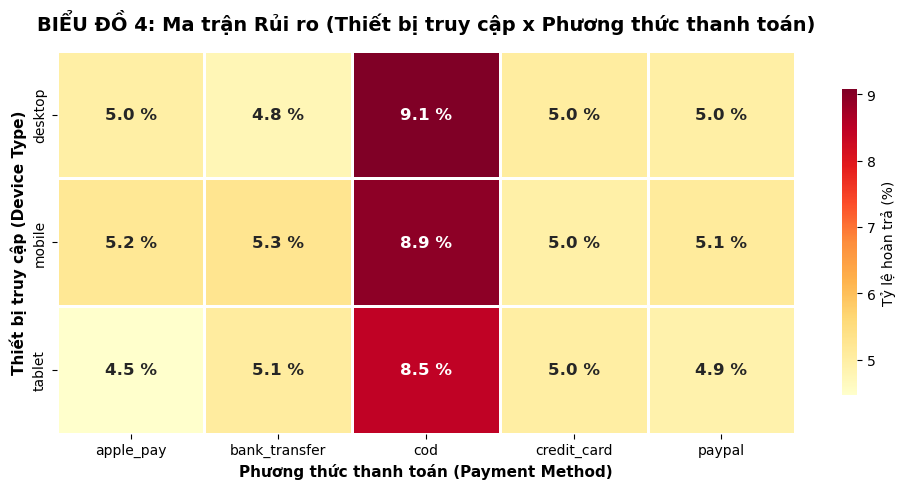

In [11]:
# 1. Join thêm cột device_type từ bảng orders (nếu chưa có trong df_base)
if 'device_type' not in df_base.columns:
    df_base = pd.merge(df_base, df_orders[['order_id', 'device_type']], on='order_id', how='left')

# 2. Xây dựng Ma trận 2 chiều (Pivot Table): Device Type x Payment Method
# Tính giá trị trung bình (mean) của is_returned, sau đó nhân 100 để ra Phần trăm (%)
risk_matrix = df_base.pivot_table(
    index='device_type', 
    columns='payment_method', 
    values='is_returned', 
    aggfunc='mean'
) * 100

# (Tùy chọn) Sắp xếp lại thứ tự cột/hàng để ma trận đẹp hơn (nếu cần)
# Giả sử chúng ta chỉ muốn tập trung vào các phương thức chính, loại bỏ các cột nhiễu nếu có
# risk_matrix = risk_matrix[['cod', 'credit_card', 'paypal', 'apple_pay', 'bank_transfer']]

# 3. Vẽ biểu đồ Heatmap Ma trận rủi ro
plt.figure(figsize=(10, 5))

# Sử dụng cmap="YlOrRd" (Vàng -> Cam -> Đỏ) để thể hiện mức độ nguy hiểm
ax = sns.heatmap(risk_matrix, annot=True, fmt=".1f", cmap="YlOrRd", 
                 linewidths=1, linecolor='white', 
                 cbar_kws={'label': 'Tỷ lệ hoàn trả (%)', 'shrink': 0.8},
                 annot_kws={'size': 12, 'weight': 'bold'})

# Thêm ký hiệu % vào các ô số liệu cho trực quan
for t in ax.texts:
    t.set_text(t.get_text() + " %")

plt.title('BIỂU ĐỒ 4: Ma trận Rủi ro (Thiết bị truy cập x Phương thức thanh toán)', 
          fontweight='bold', fontsize=14, pad=15)
plt.ylabel('Thiết bị truy cập (Device Type)', fontsize=11, fontweight='bold')
plt.xlabel('Phương thức thanh toán (Payment Method)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


### 3. Nhận xét Chẩn đoán (Diagnostic Insights):

- **Sức mạnh tuyệt đối của COD (The Red Pillar):** Điểm đập vào mắt đầu tiên của Ma trận Rủi ro là một cột đỏ rực chạy dọc theo phương thức `COD` xuyên suốt mọi thiết bị (từ 8.5% đến 9.1%). Trong khi đó, toàn bộ vùng còn lại của các phương thức trả trước (Prepaid) đều được nhuộm một màu vàng an toàn (khoảng 4.5% - 5.3%). Điều này khẳng định lại một cách đanh thép: COD là cội nguồn của khủng hoảng hoàn trả, bất chấp khách hàng dùng thiết bị gì.
- **Phá vỡ định kiến "Xung động Mobile" (Mobile Impulse Myth):** Giả thuyết ban đầu của chúng ta là: *"Giao diện Mobile gây ra sự bốc đồng và nhầm lẫn, dẫn đến tỷ lệ trả hàng cao nhất"*. Tuy nhiên, ô rực lửa nhất trong ma trận lại gọi tên tổ hợp **Desktop x COD (9.1%)**, cao hơn cả Mobile x COD (8.9%). 
- **Lý giải hành vi Desktop (The Desktop Shopping Spree):** Tại sao Desktop lại rủi ro hơn? Giao diện màn hình lớn của máy tính cho phép khách hàng dễ dàng mở hàng chục tab, lướt danh mục nhanh và "gom" vô số sản phẩm vào giỏ hàng dễ dàng hơn rất nhiều so với điện thoại. Tức là, Desktop kích thích mạnh mẽ hành vi **Mua bao vây (Bracket Buying)** ở Bước 2. Khi việc "gom hàng số lượng lớn" kết hợp với "không mất tiền ngay" (COD), rủi ro trả hàng bị đẩy lên mức cực đại.

### 4. Đề xuất hành động (Prescriptive) & Tối ưu Modeling:

- **Phân bổ nguồn lực kinh doanh (Resource Allocation):** Do chênh lệch tỷ lệ hoàn trả giữa Mobile và Desktop là quá nhỏ (không có ý nghĩa thống kê lớn), doanh nghiệp **không nên** lãng phí ngân sách công nghệ để tái cấu trúc (Redesign) lại UX/UI trên App Mobile. Lỗ hổng không nằm ở cái màn hình, lỗ hổng nằm ở chính sách thanh toán. Hãy dồn 100% nỗ lực vào việc ra mắt tính năng "Kiểm soát hiển thị COD linh hoạt".
- **Lựa chọn Đặc trưng (Feature Selection cho Machine Learning):** Nhìn theo chiều ngang của ma trận, biến `device_type` tỏ ra là một "Biến yếu" (Weak Feature) vì nó không tạo ra sự thay đổi màu sắc rõ rệt giữa các dòng. Khi huấn luyện mô hình XGBoost hay Random Forest ở Notebook 03, biến này khả năng cao sẽ có Trọng số Đặc trưng (Feature Importance) rất thấp. Chúng ta có thể xem xét loại bỏ nó để tránh làm mô hình bị cồng kềnh (Overfitting).


---
## **BƯỚC 5: XÂY DỰNG HỒ SƠ RỦI RO THỰC THỂ (CUSTOMER & PRODUCT RISK PROFILES)**
### 1. Bài toán
Rủi ro trả hàng không chỉ xuất phát từ hành vi giao dịch tại thời điểm mua (như COD hay Bracket Buying), mà còn tiềm ẩn bên trong "Lịch sử" của các thực thể tham gia:
- **Khách hàng (Customer):** Có tồn tại một nhóm "Serial Returners" (Những kẻ chuyên trả hàng) hay không?
- **Sản phẩm (Product):** Có những mã sản phẩm nào dù bán rất chạy nhưng tỷ lệ khách hoàn về lại cao đột biến (do lỗi form, hình ảnh sai thực tế) không?

### 2. Động lực thực hiện
Nếu nhận diện được nhóm khách hàng "độc hại" và nhóm sản phẩm "lỗi", thuật toán Machine Learning sau này có thể tự động cảnh báo (hoặc cấm COD) ngay khi một Serial Returner đăng nhập, hoặc khi khách hàng thêm một mã "Sản phẩm rủi ro cao" vào giỏ.


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15072\1513944826.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=risky_products, x='return_rate_pct', y='product_id_str', orient='h', palette='Reds_r', ax=ax2)


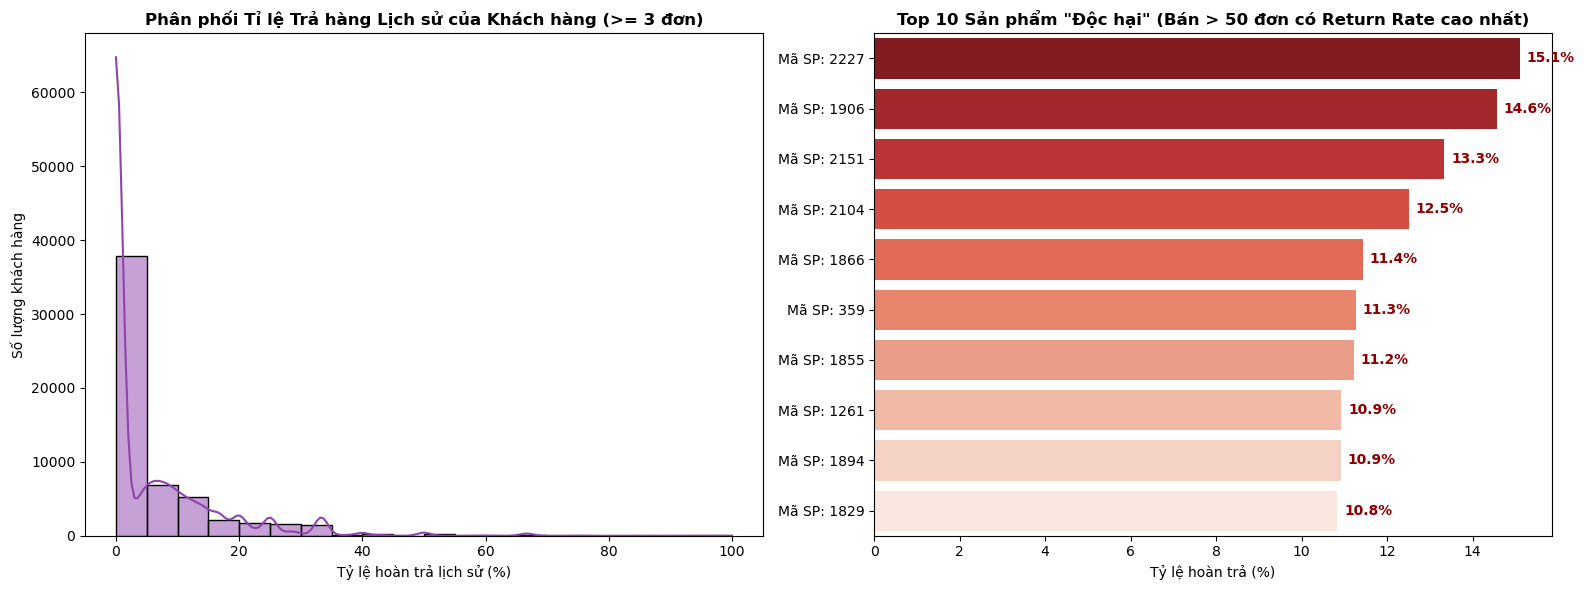

In [12]:
# 1. Customer Risk Profile (Mức độ rủi ro lịch sử của Khách hàng)
customer_risk = df_base.groupby('customer_id')['is_returned'].agg(['count', 'mean']).reset_index()
customer_risk.rename(columns={'count': 'total_orders', 'mean': 'historical_return_rate'}, inplace=True)

# Lọc những khách hàng đã mua ít nhất 3 lần để tránh nhiễu dữ liệu (những người mua 1 lần rồi trả sẽ bị 100% gây sai lệch)
loyal_customers = customer_risk[customer_risk['total_orders'] >= 3].copy()
loyal_customers['return_rate_pct'] = loyal_customers['historical_return_rate'] * 100

# 2. Product Risk Profile (Mức độ rủi ro của Mã Sản phẩm)
product_risk = df_base.groupby('product_id')['is_returned'].agg(['count', 'mean']).reset_index()
product_risk.rename(columns={'count': 'total_sold', 'mean': 'product_return_rate'}, inplace=True)

# Lọc các sản phẩm bán được ít nhất 50 đơn (đủ độ lớn mẫu) để tìm Top 10 rủi ro cao nhất
risky_products = product_risk[product_risk['total_sold'] >= 50].sort_values('product_return_rate', ascending=False).head(10)
risky_products['return_rate_pct'] = risky_products['product_return_rate'] * 100
# Convert product_id sang string để vẽ Bar chart cho đẹp
risky_products['product_id_str'] = 'Mã SP: ' + risky_products['product_id'].astype(str)

# 3. Trực quan hóa (Ghép 2 biểu đồ vào cùng 1 khung hình)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Phân phối rủi ro khách hàng (Histogram + KDE)
sns.histplot(loyal_customers['return_rate_pct'], bins=20, kde=True, color='#8e44ad', ax=ax1)
ax1.set_title('Phân phối Tỉ lệ Trả hàng Lịch sử của Khách hàng (>= 3 đơn)', fontweight='bold')
ax1.set_xlabel('Tỷ lệ hoàn trả lịch sử (%)')
ax1.set_ylabel('Số lượng khách hàng')

# Biểu đồ 2: Top 10 sản phẩm rủi ro nhất (Horizontal Bar Chart)
sns.barplot(data=risky_products, x='return_rate_pct', y='product_id_str', orient='h', palette='Reds_r', ax=ax2)
ax2.set_title('Top 10 Sản phẩm "Độc hại" (Bán > 50 đơn có Return Rate cao nhất)', fontweight='bold')
ax2.set_xlabel('Tỷ lệ hoàn trả (%)')
ax2.set_ylabel('')

# Thêm nhãn số liệu cho Biểu đồ 2
for p in ax2.patches:
    ax2.annotate(f"{p.get_width():.1f}%", (p.get_width(), p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontweight='bold', color='darkred')

plt.tight_layout()
plt.show()


Dưới đây là phần nhận xét sắc bén dựa trên chính xác những con số trong biểu đồ bạn vừa xuất ra, kèm theo một **Bản Tóm tắt (Executive Summary)** cực kỳ giá trị để bạn chốt lại toàn bộ File EDA này trước khi bước sang Machine Learning.

Bạn hãy copy đoạn này và dán vào cuối file Notebook nhé:

### 3. Nhận xét Chẩn đoán Bước 3 (Diagnostic Insights):
- **Cái đuôi dài của Khách hàng "Độc hại" (The Long-tail of Serial Returners):** Nhìn vào biểu đồ phân phối bên trái, tin tốt là đại đa số khách hàng đều rất "ngoan" (tập trung ở mốc 0 - 5%). Tuy nhiên, điều đáng sợ nằm ở "cái đuôi dài" (long-tail) kéo thẳng tới mốc 40%, 60%, thậm chí có những đốm nhỏ ở 80%. Đây chính là tập khách hàng "Serial Returners" (Bom hàng chuyên nghiệp). Mặc dù chiếm số lượng nhỏ, nhóm này vắt kiệt chi phí vận hành logistics của toàn công ty.

- **Top 10 Sản phẩm "Đốt tiền" (Toxic Products):** Biểu đồ bên phải vạch mặt 10 mã sản phẩm gây thất thoát lớn nhất. Trong khi trung bình toàn sàn chỉ là 5.6%, Mã SP `2227` và `1906` có tỷ lệ hoàn trả lên tới **15.1%** và **14.6%** (cao gấp gần 3 lần mức trung bình). Đây chắc chắn không phải lỗi của khách hàng, mà là lỗi nội tại của sản phẩm (sai bảng size, chất liệu kém, hoặc hình ảnh website quá khác thực tế).

---

#  TỔNG KẾT EDA: CÁC ĐỀ XUẤT HÀNH ĐỘNG (EXECUTIVE SUMMARY)

Sau 5 bước bóc tách dữ liệu theo mô hình phân tích chẩn đoán, chúng ta đã tìm ra bức tranh toàn cảnh về "Khủng hoảng Hoàn trả". Dưới đây là tóm tắt các **Đề xuất Hành động (Prescriptive Actions)** để Khối Vận hành ngay lập tức áp dụng, đồng thời làm cơ sở để Khối Data xây dựng Mô hình Dự đoán ở giai đoạn sau:

### 1. Chiến lược Vận hành & Business Rules (Quick Wins)
*   **Trừng phạt rủi ro kép (The 3-Item Threshold):** Dữ liệu chứng minh rủi ro bùng nổ khi khách hàng gom nhiều hàng (Bracket Buying) kết hợp với trả sau. **Đề xuất:** Tự động ẩn phương thức COD đối với bất kỳ giỏ hàng nào có từ 3 sản phẩm trở lên.

*   **Giáo dục phương thức thanh toán:** Không cấm COD toàn diện, nhưng cần tung ra các chiến dịch *"Giảm thêm 5% hoặc Freeship 100% nếu thanh toán qua Apple Pay/Credit Card"*. Chi phí giảm giá rẻ hơn rất nhiều so với gánh nặng Logistics ngược (do tỷ lệ hoàn của thẻ chỉ là 5.0% so với 8.9% của COD).

*   **Đóng băng Sản phẩm Lỗi:** Khối Operations cần lập tức rút mã SP `2227` và `1906` khỏi kho trung tâm để kiểm định lại chất lượng hoặc chụp lại ảnh thực tế trước khi cho phép bán tiếp.

*   **Tự tin chạy Mega Sale:** Việc giảm giá sâu (>30%) đã được chứng minh là KHÔNG làm tăng tỷ lệ hoàn trả. Team Marketing có thể tự tin đẩy mạnh xả kho cuối mùa mà không sợ rủi ro "FOMO Buyers".

### 2. Tiền đề cho Machine Learning (Feature Engineering Roadmap)
Để chuẩn bị cho phần model tiếp theo, tập dữ liệu huấn luyện (Training Set) cần được thiết kế dựa trên các Insight sau:
*   **Strong Features (Giữ lại & Tăng trọng số):** `payment_method_cod`, `historical_return_rate` (từ Khách hàng), `product_return_rate` (từ Sản phẩm), và đặc biệt là biến tự tạo `is_toxic_combo` (COD x Bracket >= 3).

*   **Weak Features (Nên loại bỏ để giảm nhiễu):** `discount_amount` và `discount_pct` (đã chứng minh là đường Flatline, không có phương sai dự báo). Biến `device_type` cũng có thể bỏ qua vì chênh lệch giữa Mobile và Desktop không đáng kể.

*   **Phương pháp huấn luyện:** Bắt buộc áp dụng `SMOTE` hoặc kỹ thuật `Class Weighting` vì tỷ lệ hoàn trả chỉ nằm ở mức thiểu số (5.6%). Tuyệt đối không dùng Accuracy làm thước đo, thay vào đó phải tối ưu hóa chỉ số **F1-Score** và **PR-AUC**.